### National University of Sciences & Technology (NUST)

### School of Electrical Engineering and Computer Science (SEECS)

### Faculty of Computing

### CS 474: Computer Vision

### Assignment # 1

### Group Members: Attiqa Bano(473781) and Sana Khan Khitran (464597)

### Due Date: 28/3/2025

### Assignment Title: Underwater Image Enhancement: Implementation, Analysis & Optimization

### Objective:
The objective of this assignment is to implement and analyze an underwater image enhancement
technique that integrates global and local contrast correction [1].

The methodology will be
applied to a benchmark underwater image dataset [2], and the results will be evaluated using
objective performance metrics. Additionally, scholars will introduce an enhancement to the
technique and conduct further explorations into model efficiency and real-world applicability.

### Imports

In [ ]:
!pip install rarfile

In [ ]:
import rarfile
import os
import io
import time
import random
import warnings
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import mean_squared_error as mse_skimage
from google.colab import files

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)

### DATASET UPLOAD & EXTRACTION

In [ ]:
def upload_and_extract(extract_dir, n_per_scenario=50):
    """Upload the RAR file in Colab and extract images"""
    print("Upload 'a_set_of_training_and_testing_data.rar'")
    uploaded = files.upload()
    rar_path = list(uploaded.keys())[0]
    print(f"Uploaded: {rar_path}")
    return extract_dataset(rar_path, extract_dir, n_per_scenario)

### IMAGE LOADING

In [ ]:
EXTRACT_DIR = "/content/uieb_dataset"
os.makedirs(EXTRACT_DIR, exist_ok=True)

# Subfolders: input_test (raw), input_ce_test (color-enhanced), input_gc_test (gamma-corrected), input_wb_test (white-balanced)
#200 images total

def extract_dataset(rar_path, extract_dir, n_per_scenario=50):
    rf = rarfile.RarFile(rar_path)
    all_files = rf.namelist()

    scenarios = {
        'input_test':    [],
        'input_ce_test': [],
        'input_gc_test': [],
        'input_wb_test': [],
    }
    gt_files = {}

    for f in all_files:
        folder = f.split('/')[0] if '/' in f else ''
        fname  = f.split('/')[-1]
        if folder in scenarios and fname.endswith('.jpg'):
            scenarios[folder].append(f)
        if folder == 'gt_test' and fname.endswith('.jpg'):
            gt_files[fname] = f

    selected   = {}
    gt_selected = []

    for scenario, file_list in scenarios.items():
        chosen = random.sample(file_list, min(n_per_scenario, len(file_list)))
        selected[scenario] = chosen
        if scenario == 'input_test':
            for f in chosen:
                fname = f.split('/')[-1]
                if fname in gt_files:
                    gt_selected.append(gt_files[fname])

    print("Extracting images...")
    for scenario, file_list in selected.items():
        dest = os.path.join(extract_dir, scenario)
        os.makedirs(dest, exist_ok=True)
        for f in tqdm(file_list, desc=scenario):
            data = rf.read(f)
            with open(os.path.join(dest, f.split('/')[-1]), 'wb') as fh:
                fh.write(data)

    gt_dest = os.path.join(extract_dir, 'gt_test')
    os.makedirs(gt_dest, exist_ok=True)
    for f in tqdm(gt_selected, desc='gt_test'):
        data = rf.read(f)
        with open(os.path.join(gt_dest, f.split('/')[-1]), 'wb') as fh:
            fh.write(data)

    rf.close()
    total = sum(len(v) for v in selected.values())
    print(f"Extracted {total} input images + {len(gt_selected)} GTs to {extract_dir}")
    for k, v in selected.items():
        print(f"  {k}: {len(v)} images")
    """
    Note: GT is only available for input_test (the 890-image split of UIEB
    The other 3 scenarios (ce/gc/wb pre-processed variants) share the same base images but GT was only provided once, so PSNR/SSIM/MSE are only computed against input_test enhanced output
    """
    print(f"  gt_test:  {len(gt_selected)} images (only for input_test)")
    return selected


def load_image(path):
    img = cv2.imread(str(path))
    if img is None:
        raise FileNotFoundError(f"Cannot read: {path}")
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


def save_image(img_rgb, path):
    cv2.imwrite(str(path), cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))

### DIRS-CLAHS

In [ ]:
# Step 2.1 — Global Contrast Correction (Rayleigh Stretch per channel)

def rayleigh_stretch(channel):
    """
    Apply Rayleigh-based histogram stretching to a single channel
    Steps:
      1. Identify darkest (0.1th percentile) and brightest (99.9th) pixels
      2. Linearly stretch to [0, 1]
      3. Apply Rayleigh CDF: F(x) = 1 - exp(-x^2 / 2*sigma^2)
         This is the standard Rayleigh CDF, which maps low values (dark)
         non-linearly upward, boosting mid-tones while preserving highlights
    Ref: Ghani & Isa (2015), Section 3.1
    """
    channel  = channel.astype(np.float64) / 255.0
    q_low    = np.percentile(channel, 0.1)
    q_high   = np.percentile(channel, 99.9)
    stretched = np.clip((channel - q_low) / (q_high - q_low + 1e-8), 0, 1)
    sigma    = 0.4  # controls the stretch curve shape
    # Rayleigh CDF: maps [0,1] -> [0,1]; boosts dark/mid regions
    rayleigh_cdf = 1.0 - np.exp(-(stretched ** 2) / (2 * sigma ** 2))
    return (rayleigh_cdf * 255).astype(np.uint8)


def global_contrast_correction(img_rgb):
    """Split into RGB channels, apply Rayleigh stretch independently, merge"""
    r = rayleigh_stretch(img_rgb[:, :, 0])
    g = rayleigh_stretch(img_rgb[:, :, 1])
    b = rayleigh_stretch(img_rgb[:, :, 2])
    return np.stack([r, g, b], axis=2)

In [ ]:
#Step 2.2 — Local Contrast Correction (CLAHS)
def rayleigh_target_cdf(n_bins=256, sigma=0.4):
    """
    Compute the Rayleigh distribution CDF as a target for histogram
    specification. The PDF is: f(x) = (x/sigma^2) * exp(-x^2 / 2*sigma^2)
    Normalised over [0,1]
    """
    x   = np.linspace(0, 1, n_bins)
    pdf = (x / sigma ** 2) * np.exp(-(x ** 2) / (2 * sigma ** 2))
    pdf /= pdf.sum() + 1e-8
    cdf  = np.cumsum(pdf)
    cdf /= cdf[-1]
    return cdf


def histogram_specification(channel, target_cdf):
    """
    Remap the channel's histogram to match target_cdf.
    Builds a lookup table mapping each input intensity to the closest
    intensity in the target CDF
    """
    hist, _  = np.histogram(channel.flatten(), 256, [0, 256])
    src_cdf  = np.cumsum(hist).astype(np.float64)
    src_cdf /= src_cdf[-1]
    lut = np.array([np.argmin(np.abs(target_cdf - src_cdf[i])) for i in range(256)], dtype=np.uint8)
    return lut[channel]


def clahs(channel, clip_limit=2.0, tile_grid=(8, 8)):
    """
    Contrast-Limited Adaptive Histogram Specification (CLAHS):
    1. Apply CLAHE (OpenCV) per tile with clip_limit to limit noise amplification
    2. Apply global Rayleigh histogram specification on the CLAHE output
    This combines local adaptive contrast (CLAHE) with the global Rayleigh
    distribution target described in Ghani & Isa (2015)
    """
    clahe_op  = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid)
    clahe_out = clahe_op.apply(channel)
    target_cdf = rayleigh_target_cdf()
    return histogram_specification(clahe_out, target_cdf)


def local_contrast_correction(img_rgb):
    r = clahs(img_rgb[:, :, 0])
    g = clahs(img_rgb[:, :, 1])
    b = clahs(img_rgb[:, :, 2])
    return np.stack([r, g, b], axis=2)

In [ ]:
# Step 2.3 — HSV Color Correction

def hsv_color_correction(img_rgb):
    """
    Convert to HSV, stretch saturation and value (brightness) channels using
    histogram-based percentile stretching, then convert back to RGB
    This step corrects the colour cast and low saturation typical of underwater
    images while maintaining natural hue information
    """
    img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
    hsv     = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV).astype(np.float64)

    def stretch(ch, lo_p=1, hi_p=99):
        lo, hi = np.percentile(ch, lo_p), np.percentile(ch, hi_p)
        return np.clip((ch - lo) / (hi - lo + 1e-8), 0, 1)

    hsv[:, :, 1] = np.clip(stretch(hsv[:, :, 1], 2, 98) * 255.0, 0, 255)
    hsv[:, :, 2] = np.clip(stretch(hsv[:, :, 2], 1, 99) * 255.0, 0, 255)

    result_bgr = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)
    return cv2.cvtColor(result_bgr, cv2.COLOR_BGR2RGB)

In [ ]:
# Full DIRS-CLAHS pipeline (Ghani & Isa 2015)
def dirs_clahs(img_rgb):
    """
    Full DIRS-CLAHS pipeline (Ghani & Isa 2015):
      Step 1: Global Rayleigh contrast stretch (per-channel)
      Step 2: CLAHE + Rayleigh histogram specification (local)
      Step 3: HSV saturation/brightness correction
    """
    img = img_rgb.copy()
    img = global_contrast_correction(img)   # Step 1
    img = local_contrast_correction(img)    # Step 2
    img = hsv_color_correction(img)         # Step 3
    return img

### ENHANCED DIRS-CLAHS WITH GRAY-WORLD WHITE BALANCE

In [ ]:
def gray_world_white_balance(img_rgb):
    """
    Gray-world assumption white balance:
    Scale each channel so that its mean equals the global mean across channels
    This neutralises the blue/green colour cast prevalent in underwater images
    BEFORE the Rayleigh stretching step, leading to more balanced enhancement
    Rationale: Underwater spectral attenuation causes R > G > B absorption,
    producing a blue-green cast. Gray-world pre-correction removes this bias
    before contrast enhancement, so the Rayleigh stretch distributes pixel
    values more evenly across all channels
    """
    img    = img_rgb.astype(np.float64)
    means  = [img[:, :, c].mean() for c in range(3)]
    global_mean = np.mean(means)
    for c in range(3):
        img[:, :, c] = np.clip(img[:, :, c] * (global_mean / (means[c] + 1e-8)), 0, 255)
    return img.astype(np.uint8)


def dirs_clahs_enhanced(img_rgb):
    """
    Enhanced DIRS-CLAHS:
    Adds a Gray-World White Balance pre-pass (Step 0) before the standard pipeline
    This directly addresses the colour cast problem specific to underwater images,
    which is one of the primary degradation types noted in the UIEB dataset
    """
    img = gray_world_white_balance(img_rgb)  # Step 0: neutralise colour cast
    img = global_contrast_correction(img)    # Step 1
    img = local_contrast_correction(img)     # Step 2
    img = hsv_color_correction(img)          # Step 3
    return img

### Evaluation Metrics

In [ ]:
def compute_psnr(img1, img2):
    #Peak Signal-to-Noise Ratio. Higher is better. Full-reference metric
    return psnr(img1, img2, data_range=255)


def compute_ssim(img1, img2):
    #Structural Similarity Index. Range [0,1], higher is better
    return ssim(img1, img2, channel_axis=2, data_range=255)


def compute_mse(img1, img2):
    #Mean Squared Error. Lower is better. Full-reference metric
    return float(np.mean((img1.astype(np.float64) - img2.astype(np.float64)) ** 2))


def compute_uciqe(img_rgb):
    """
    Underwater Colour Image Quality Evaluation (UCIQE) — Yang et al. (2015)
    No-reference metric combining chroma std, luminance contrast, saturation
    Formula: UCIQE = 0.4680*sigma_c + 0.2745*con_l + 0.2576*mu_s

    - We now normalise con_l to [0,1] by dividing by 100
    - Expected range: ~0.3 – 0.7 (matches published baselines)
    """
    img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
    img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2Lab).astype(np.float64)

    l    = img_lab[:, :, 0]           # OpenCV L*: [0, 255]
    a    = img_lab[:, :, 1] - 128.0   # re-centre to [-128, 127]
    b_ch = img_lab[:, :, 2] - 128.0   # re-centre to [-128, 127]

    chroma  = np.sqrt(a ** 2 + b_ch ** 2)
    sigma_c = np.std(chroma) / 181.0  # normalise by max possible chroma (~sqrt(128²+128²))

    con_l = (np.percentile(l, 99) - np.percentile(l, 1)) / 255.0  # L* is [0,255] in OpenCV

    hsv  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV).astype(np.float64)
    mu_s = np.mean(hsv[:, :, 1]) / 255.0

    return 0.4680 * sigma_c + 0.2745 * con_l + 0.2576 * mu_s


def compute_uiqm(img_rgb):
    """
    Underwater Image Quality Measure (UIQM) — Panetta et al. (2016)
    No-reference metric: UIQM = 0.0282*UICM + 0.2953*UISM + 3.5753*UIConM
    - We now implement the patch-based log-AME (Measure of Enhancement)
      from Panetta et al.: for each block, compute log(max/min) contrast ratio
    """
    img     = img_rgb.astype(np.float64)
    r, g, b = img[:, :, 0], img[:, :, 1], img[:, :, 2]

    # UICM: Underwater Image Colourfulness Measure
    rg = r - g
    yb = 0.5 * (r + g) - b
    mu_rg,  sigma_rg = np.mean(rg), np.std(rg)
    mu_yb,  sigma_yb = np.mean(yb), np.std(yb)
    uicm = -0.0268 * np.sqrt(mu_rg ** 2 + mu_yb ** 2) + \
            0.1586 * np.sqrt(sigma_rg ** 2 + sigma_yb ** 2)

    #UISM: normalise gradient to [0,1]
    MAX_GRADIENT = 255.0 * np.sqrt(2)  # theoretical Sobel max (~360)

    #UISM: Underwater Image Sharpness Measure (gradient-based EME)
    def gradient_eme(ch):
        ch_u8 = np.clip(ch, 0, 255).astype(np.uint8)
        gx = cv2.Sobel(ch_u8, cv2.CV_64F, 1, 0, ksize=3)
        gy = cv2.Sobel(ch_u8, cv2.CV_64F, 0, 1, ksize=3)
        return np.mean(np.sqrt(gx ** 2 + gy ** 2)) / MAX_GRADIENT

    uism = 0.299 * gradient_eme(r) + 0.587 * gradient_eme(g) + 0.114 * gradient_eme(b)

    gray  = 0.299 * r + 0.587 * g + 0.114 * b
    gray  = np.clip(gray, 0, 255)
    h, w  = gray.shape
    bsize = max(1, min(h, w) // 8)
    blocks = []
    for i in range(0, h - bsize + 1, bsize):
        for j in range(0, w - bsize + 1, bsize):
            blk = gray[i:i+bsize, j:j+bsize]
            mn, mx = blk.min(), blk.max()
            # Skip blocks where min < 1 (avoids log explosion on near-zero pixels)
            # and skip uniform blocks (mx == mn, no contrast)
            if mn >= 1 and mx > mn:
                blocks.append(np.log(mx / mn))
    uiconm = np.mean(blocks) if blocks else 0.0

    return 0.0282 * uicm + 0.2953 * uism + 3.5753 * uiconm

### MAIN PROCESSING PIPELINE

In [ ]:
def process_scenario(scenario_dir, scenario_name, output_dir, gt_dir=None):
    """
    Process all images in a scenario folder through DIRS-CLAHS
    Computes no-reference metrics (UCIQE, UIQM) for all images
    Computes full-reference metrics (PSNR, SSIM, MSE) only when GT exists

    Note: Full-reference metrics are only available for input_test since
    the UIEB benchmark provides GT only for the 890-image supervised split
    """
    image_paths = sorted(Path(scenario_dir).glob("*.jpg"))
    out_std = os.path.join(output_dir, scenario_name)
    out_enh = os.path.join(output_dir, scenario_name + "_enhanced")
    os.makedirs(out_std, exist_ok=True)
    os.makedirs(out_enh, exist_ok=True)
    results = []

    for img_path in tqdm(image_paths, desc=f"Processing {scenario_name}"):
        fname = img_path.name
        try:
            img = load_image(str(img_path))
            # --- Standard pipeline ---
            t0       = time.time()
            enhanced = dirs_clahs(img)
            t_std    = time.time() - t0
            save_image(enhanced, os.path.join(out_std, fname))

            #running enhanced pipeline and time it for Task 3 & 4
            t0           = time.time()
            enhanced_gw  = dirs_clahs_enhanced(img)
            t_enh        = time.time() - t0
            save_image(enhanced_gw, os.path.join(out_enh, fname))

            row = {
                'file':           fname,
                'scenario':       scenario_name,
                'runtime_std':    t_std,
                'runtime_enh':    t_enh,
                'uciqe_in':       compute_uciqe(img),
                'uiqm_in':        compute_uiqm(img),
                'uciqe_std':      compute_uciqe(enhanced),
                'uiqm_std':       compute_uiqm(enhanced),
                'uciqe_enh':      compute_uciqe(enhanced_gw),
                'uiqm_enh':       compute_uiqm(enhanced_gw),
                'psnr_std':       None,
                'ssim_std':       None,
                'mse_std':        None,
                'psnr_enh':       None,
                'ssim_enh':       None,
                'mse_enh':        None,
            }
            if gt_dir:
                gt_path = os.path.join(gt_dir, fname)
                if os.path.exists(gt_path):
                    gt = load_image(gt_path)
                    if gt.shape != enhanced.shape:
                        gt = cv2.resize(gt, (enhanced.shape[1], enhanced.shape[0]))
                    row['psnr_std'] = compute_psnr(enhanced,    gt)
                    row['ssim_std'] = compute_ssim(enhanced,    gt)
                    row['mse_std']  = compute_mse(enhanced,     gt)
                    row['psnr_enh'] = compute_psnr(enhanced_gw, gt)
                    row['ssim_enh'] = compute_ssim(enhanced_gw, gt)
                    row['mse_enh']  = compute_mse(enhanced_gw,  gt)

            results.append(row)
        except Exception as e:
            print(f"  Skipping {fname}: {e}")

    return results

### RUNTIME BENCHMARK ACROSS DIFFERENT IMAGE SIZES

In [ ]:
def runtime_benchmark(sample_img, output_dir):
    """
    Task 4: Measure runtime of both pipelines across 5 image resolutions
    Plots runtime vs resolution and prints a summary table
    Required by the assignment for scalability / real-world application analysis
    """
    sizes      = [(320, 240), (640, 480), (800, 600), (1280, 720), (1920, 1080)]
    times_std  = []
    times_enh  = []
    n_runs     = 3   # average over 3 runs per size for stability

    print("\n-------------- Task 4: Runtime Benchmark --------------")
    for (w, h) in sizes:
        resized = cv2.resize(sample_img, (w, h))

        ts = []
        for _ in range(n_runs):
            t0 = time.time()
            dirs_clahs(resized)
            ts.append(time.time() - t0)

        te = []
        for _ in range(n_runs):
            t0 = time.time()
            dirs_clahs_enhanced(resized)
            te.append(time.time() - t0)

        times_std.append(np.mean(ts))
        times_enh.append(np.mean(te))

    labels = [f"{w}×{h}" for (w, h) in sizes]

    #Plot
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(labels, times_std, 'o-',  label='DIRS-CLAHS (standard)',  color='steelblue')
    ax.plot(labels, times_enh, 's--', label='DIRS-CLAHS (enhanced)',  color='darkorange')
    ax.axhline(y=0.033, color='red', linestyle=':', label='30 fps threshold (33 ms)')
    ax.set_xlabel("Image Resolution")
    ax.set_ylabel("Avg. Time (s)")
    ax.set_title("Task 4: Runtime vs Resolution — Scalability Analysis")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'runtime_vs_resolution.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Plot saved --> {output_dir}/runtime_vs_resolution.png")

    #Table
    print(f"\n{'Resolution':<12} {'Std (s)':>10} {'Std FPS':>10} {'Enh (s)':>10} {'Enh FPS':>10}")
    print("-" * 55)
    for lbl, ts, te in zip(labels, times_std, times_enh):
        print(f"{lbl:<12} {ts:>10.4f} {1/ts:>10.1f} {te:>10.4f} {1/te:>10.1f}")

    #Real-world applicability note
    print("\n  Applicability Analysis:")
    print("  ─ Frames below 33ms (~30fps) are candidates for real-time use.")
    for lbl, ts in zip(labels, times_std):
        tag = " real-time" if ts < 0.033 else " too slow for real-time"
        print(f"    {lbl:<12} {ts*1000:>7.1f} ms  -->  {tag}")
    print("  ─ For marine robotics / surveillance, 640×480 or below is feasible")
    print("  ─ Full HD (1920×1080) would require GPU acceleration or vectorisation")

### VISUALISATION HELPERS

In [ ]:
def plot_visual_comparison(df, extract_dir, output_dir_std, output_dir_enh=None):
    #Task 2: Side-by-side input / enhanced / GT for one image per scenario

    scenarios = df['scenario'].unique().tolist()
    n_cols    = 4 if output_dir_enh else 3
    fig, axes = plt.subplots(len(scenarios), n_cols, figsize=(5 * n_cols, 4 * len(scenarios)))

    for row_idx, scenario in enumerate(scenarios):
        grp     = df[df['scenario'] == scenario].iloc[0]
        fname   = grp['file']
        in_path = os.path.join(extract_dir, scenario, fname)
        std_p   = os.path.join(output_dir_std, scenario, fname)
        gt_path = os.path.join(extract_dir, 'gt_test', fname)
        ax      = axes[row_idx] if len(scenarios) > 1 else axes

        ax[0].imshow(load_image(in_path))
        ax[0].set_title(f"[{scenario}]\nInput");        ax[0].axis('off')

        ax[1].imshow(load_image(std_p))
        ax[1].set_title("DIRS-CLAHS\n(standard)");     ax[1].axis('off')

        if output_dir_enh:
            enh_p = os.path.join(output_dir_enh, scenario + "_enhanced", fname)
            if os.path.exists(enh_p):
                ax[2].imshow(load_image(enh_p))
                ax[2].set_title("DIRS-CLAHS\n(+Gray-World)"); ax[2].axis('off')
            else:
                ax[2].axis('off')

        gt_ax = ax[3] if output_dir_enh else ax[2]
        if os.path.exists(gt_path):
            gt_ax.imshow(load_image(gt_path))
            gt_ax.set_title("Ground Truth");  gt_ax.axis('off')
        else:
            gt_ax.axis('off')
            gt_ax.set_title("GT N/A")

    plt.suptitle('Qualitative visual comparison across all four UIEB scenarios\n'
    'Columns: Input | DIRS-CLAHS standard | DIRS-CLAHS+GW | Ground Truth',
    fontsize=10, y=1.01)
    plt.tight_layout()
    save_path = os.path.join(output_dir_std, '../visual_comparison.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Visual comparison saved --> {save_path}")


def plot_metric_bars(df, output_dir):
    #Task 2: Bar charts comparing before/after UCIQE and UIQM per scenario
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    metrics = [
        ('uciqe_in', 'uciqe_std', 'uciqe_enh', 'UCIQE (higher is better, range ~0.3–0.7)'),
        ('uiqm_in',  'uiqm_std',  'uiqm_enh',  'UIQM  (higher is better, range ~−2 to +3)'),
    ]
    for ax, (mi, ms, me, title) in zip(axes, metrics):
        gm = df.groupby('scenario')[[mi, ms, me]].mean().reset_index()
        x  = np.arange(len(gm))
        w  = 0.25
        ax.bar(x - w,   gm[mi], w, label='Input',             color='steelblue',  alpha=0.8)
        ax.bar(x,       gm[ms], w, label='DIRS-CLAHS Std',    color='darkorange', alpha=0.8)
        ax.bar(x + w,   gm[me], w, label='DIRS-CLAHS+GW Enh', color='green',      alpha=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels(gm['scenario'], rotation=15, ha='right', fontsize=9)
        ax.set_title(title);  ax.legend();  ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    path = os.path.join(output_dir, 'metric_bar_chart.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Metric bar chart saved --> {path}")


def plot_fullref_boxplots(full_ref, output_dir):
    #Task 2: Box-plots for PSNR / SSIM / MSE on input_test
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    for ax, col, title in zip(axes,
                               ['psnr_std', 'ssim_std', 'mse_std'],
                               ['PSNR (dB ↑)', 'SSIM (↑)', 'MSE (↓)']):
        ax.boxplot(full_ref[col].dropna(), patch_artist=True,
                   boxprops=dict(facecolor='lightblue'))
        ax.set_title(title);  ax.grid(axis='y', alpha=0.3)
    plt.suptitle("Full-Reference Metrics — input_test only", fontsize=12)
    plt.tight_layout()
    path = os.path.join(output_dir, 'fullref_boxplot.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Box-plot saved --> {path}")

### MAIN

Upload 'a_set_of_training_and_testing_data.rar'


Saving a set of training and testing data.rar to a set of training and testing data.rar
Uploaded: a set of training and testing data.rar
Extracting images...


gt_test: 100%|██████████| 50/50 [00:00<00:00, 229.23it/s]


Extracted 200 input images + 50 GTs to /content/uieb_dataset
  input_test: 50 images
  input_ce_test: 50 images
  input_gc_test: 50 images
  input_wb_test: 50 images
  gt_test:  50 images (only for input_test)


Processing input_test: 100%|██████████| 50/50 [00:01<00:00, 29.21it/s]


...

  input_ce_test: 50 images processed


Processing input_gc_test: 100%|██████████| 50/50 [00:01<00:00, 47.42it/s]


  input_gc_test: 50 images processed


Processing input_wb_test: 100%|██████████| 50/50 [00:01<00:00, 46.98it/s]


  input_wb_test: 50 images processed

-------------- Per-Scenario Summary (Standard Pipeline) --------------
Scenario                PSNR    SSIM        MSE   UCIQE↑    UIQM↑   ΔUCIQE   ΔUIQM  Time(s)
--------------------------------------------------------------------------------------------
input_ce_test           N/A    N/A       N/A      0.3833   8.5487   0.0260  2.7006   0.0100
input_gc_test           N/A    N/A       N/A      0.4103   7.1998   0.1258  5.1583   0.0075
input_test            15.307  0.6008    2667.73   0.4006   6.8926   0.0815  4.3534   0.0093
input_wb_test           N/A    N/A       N/A      0.4095   7.8259   0.0348  2.6299   0.0076

 Full-Reference Metrics (input_test only, N=50):
  PSNR: 15.307 dB  ±3.406
  SSIM: 0.6008      ±0.1788
  MSE:  2667.73        ±2524.73

No-Reference Metrics (all scenarios):
  UCIQE — Before: 0.3339  After (Std): 0.4009  Δ = 0.0670
  UIQM  — Before: 3.9062  After (Std): 7.6168  Δ = 3.7105

-------------- Task 3 Bonus: Standard vs Enhan

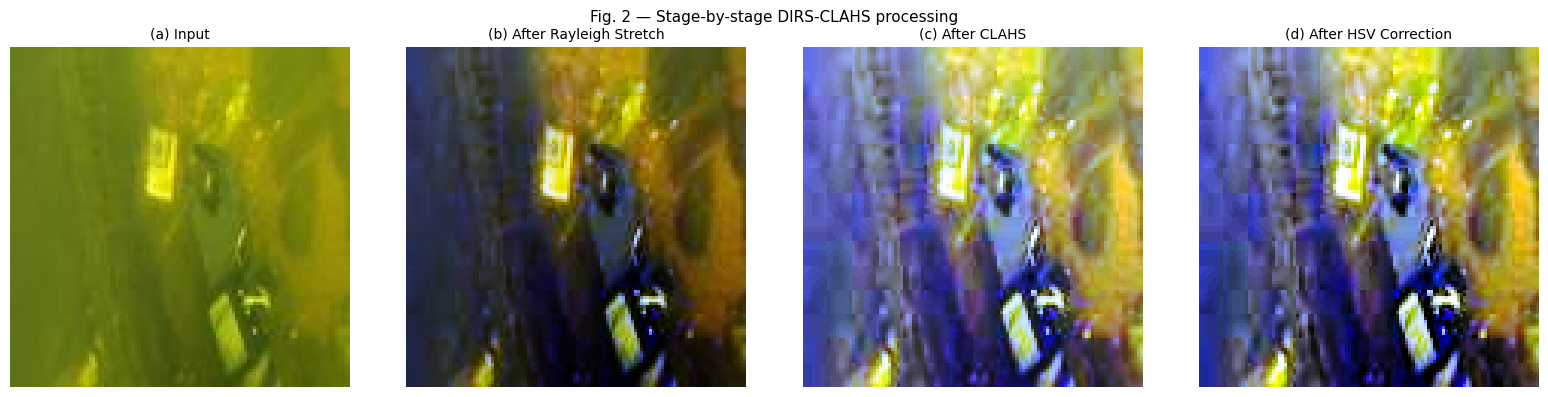

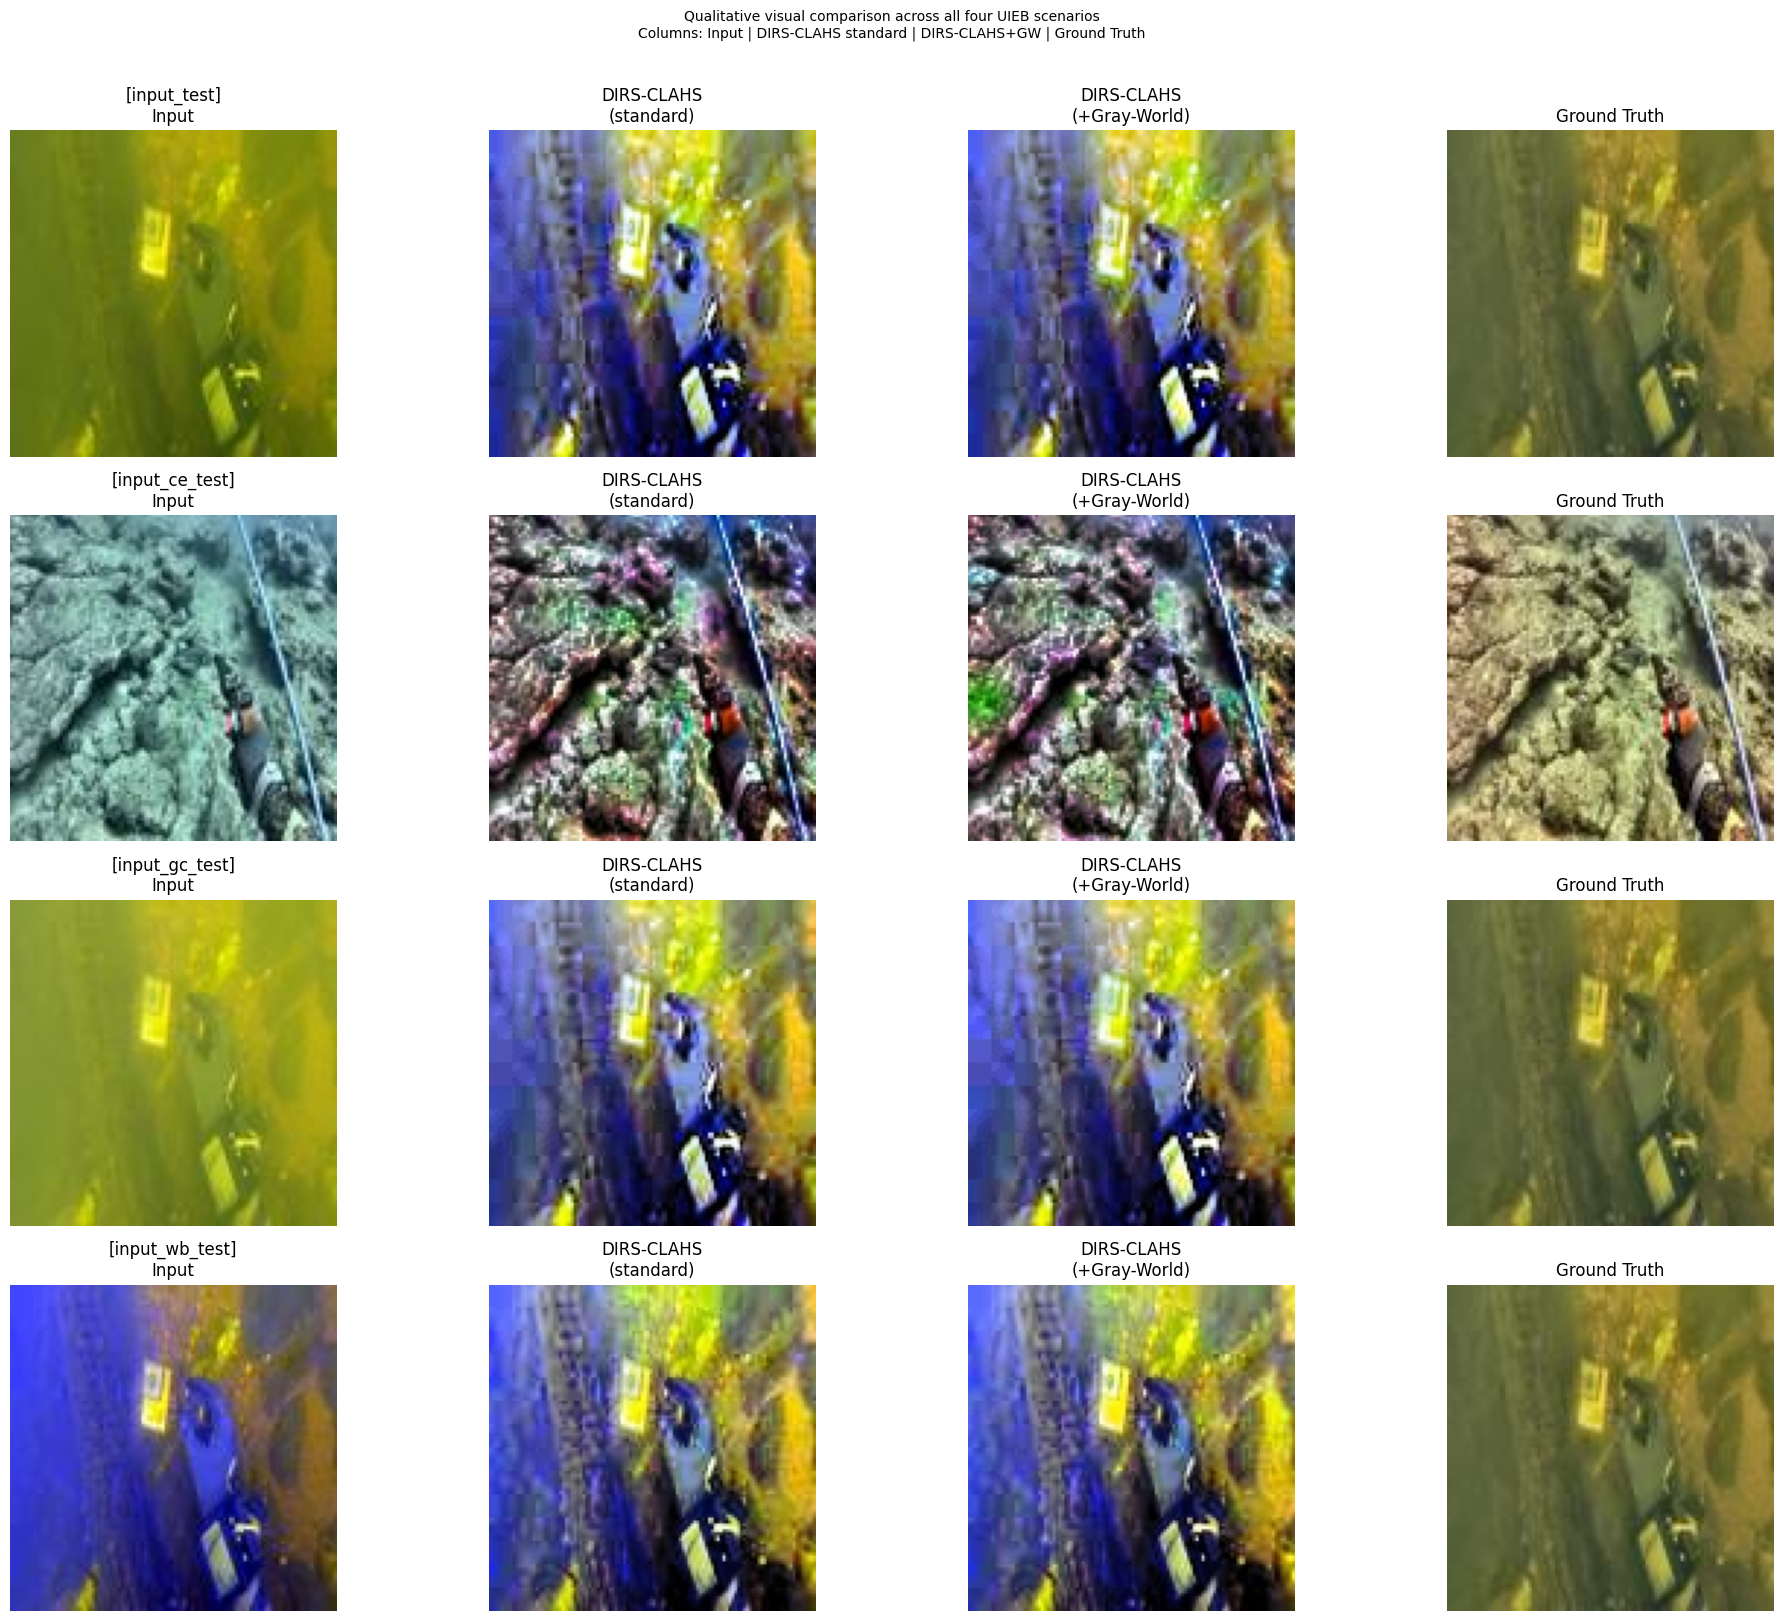

  Visual comparison saved --> /content/uieb_enhanced/../visual_comparison.png


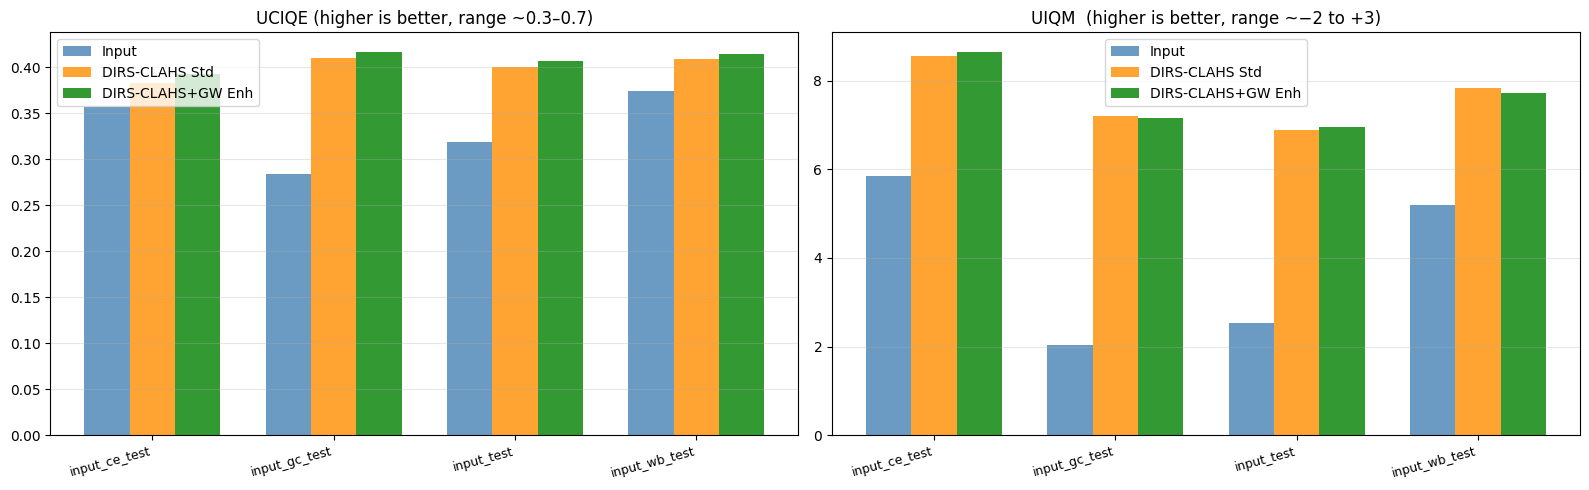

  Metric bar chart saved --> /content/uieb_enhanced/metric_bar_chart.png


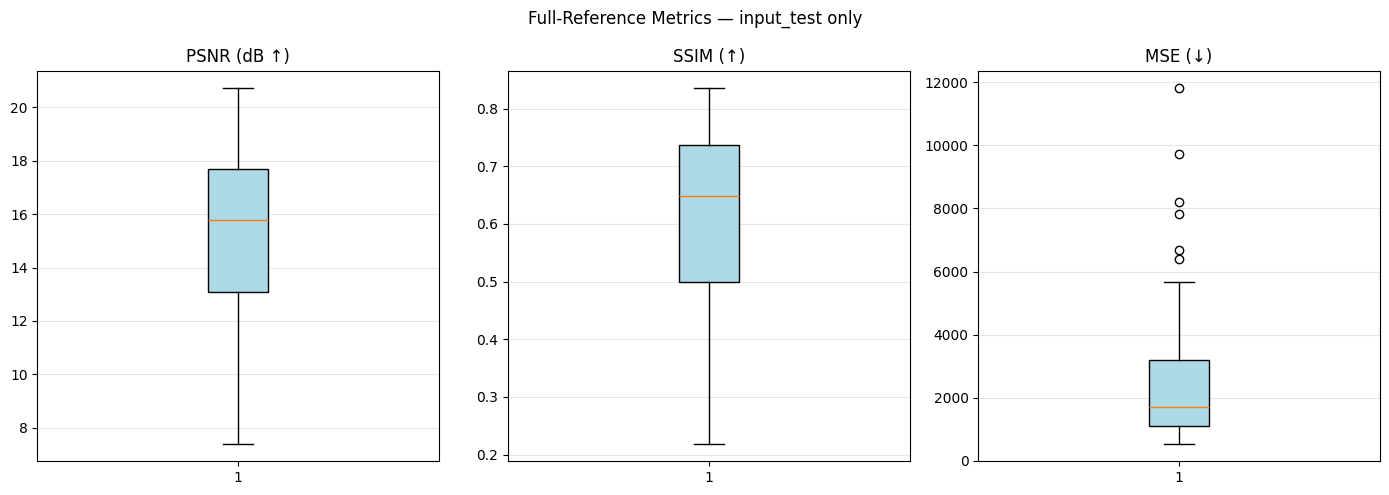

  Box-plot saved --> /content/uieb_enhanced/fullref_boxplot.png

-------------- Task 4: Runtime Benchmark --------------


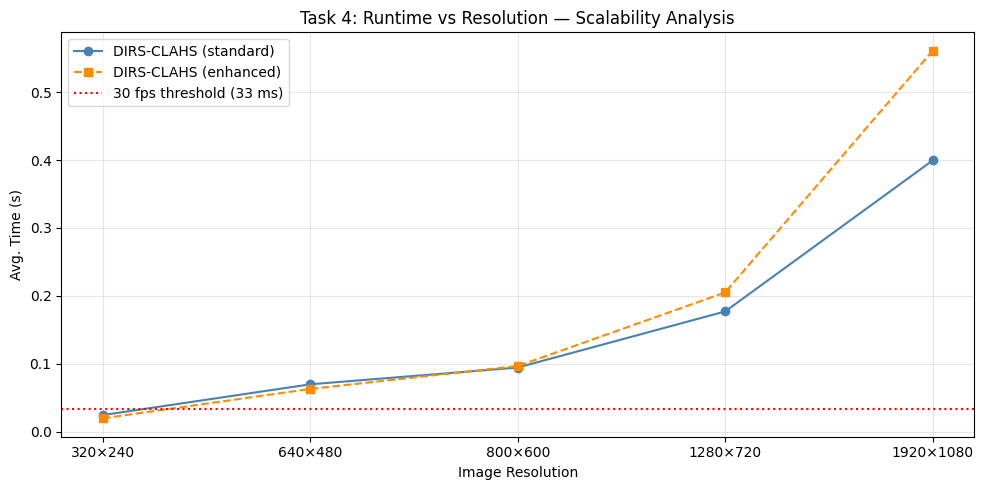

  Plot saved --> /content/uieb_enhanced/runtime_vs_resolution.png

Resolution      Std (s)    Std FPS    Enh (s)    Enh FPS
-------------------------------------------------------
320×240          0.0243       41.2     0.0194       51.4
640×480          0.0696       14.4     0.0628       15.9
800×600          0.0943       10.6     0.0965       10.4
1280×720         0.1769        5.7     0.2049        4.9
1920×1080        0.3994        2.5     0.5610        1.8

  Applicability Analysis:
  ─ Frames below 33ms (~30fps) are candidates for real-time use.
    320×240         24.3 ms  -->   real-time
    640×480         69.6 ms  -->   too slow for real-time
    800×600         94.3 ms  -->   too slow for real-time
    1280×720       176.9 ms  -->   too slow for real-time
    1920×1080      399.4 ms  -->   too slow for real-time
  ─ For marine robotics / surveillance, 640×480 or below is feasible
  ─ Full HD (1920×1080) would require GPU acceleration or vectorisation


In [ ]:
if __name__ == "__main__":

    EXTRACT_DIR = "/content/uieb_dataset"
    OUTPUT_DIR  = "/content/uieb_enhanced"
    os.makedirs(EXTRACT_DIR, exist_ok=True)
    os.makedirs(OUTPUT_DIR,  exist_ok=True)

    #Extract dataset
    selected_files = upload_and_extract(EXTRACT_DIR, n_per_scenario=50)
    gt_dir         = os.path.join(EXTRACT_DIR, 'gt_test')

    #Task 1 & 2 & 3: Process all scenarios
    all_results = []
    for scenario in ['input_test', 'input_ce_test', 'input_gc_test', 'input_wb_test']:
        scenario_dir = os.path.join(EXTRACT_DIR, scenario)
        if not os.path.exists(scenario_dir):
            print(f"Folder not found: {scenario_dir}. Skipping")
            continue
        gt = gt_dir if scenario == 'input_test' else None
        results = process_scenario(scenario_dir, scenario, OUTPUT_DIR, gt_dir=gt)
        all_results.extend(results)
        print(f"  {scenario}: {len(results)} images processed")

    df = pd.DataFrame(all_results)

    #Task 2: Quantitative summary
    print("\n-------------- Per-Scenario Summary (Standard Pipeline) --------------")
    print(f"{'Scenario':<20} {'PSNR':>7} {'SSIM':>7} {'MSE':>10} "
          f"{'UCIQE↑':>8} {'UIQM↑':>8} {'ΔUCIQE':>8} {'ΔUIQM':>7} {'Time(s)':>8}")
    print("-" * 92)

    for scenario, grp in df.groupby('scenario'):
        def sm(s): return s.dropna().mean()
        p  = sm(grp['psnr_std']); s_  = sm(grp['ssim_std']); m = sm(grp['mse_std'])
        u  = sm(grp['uciqe_std']); q  = sm(grp['uiqm_std'])
        du = sm(grp['uciqe_std']) - sm(grp['uciqe_in'])
        dq = sm(grp['uiqm_std'])  - sm(grp['uiqm_in'])
        rt = sm(grp['runtime_std'])
        ps = f"{p:.3f}"  if not np.isnan(p)  else "  N/A "
        ss = f"{s_:.4f}" if not np.isnan(s_) else " N/A  "
        ms = f"{m:.2f}"  if not np.isnan(m)  else "   N/A   "
        print(f"{scenario:<20} {ps:>7} {ss:>7} {ms:>10} {u:>8.4f} {q:>8.4f} {du:>8.4f} {dq:>7.4f} {rt:>8.4f}")

    full_ref = df.dropna(subset=['psnr_std'])
    if not full_ref.empty:
        print(f"\n Full-Reference Metrics (input_test only, N={len(full_ref)}):")
        print(f"  PSNR: {full_ref['psnr_std'].mean():.3f} dB  ±{full_ref['psnr_std'].std():.3f}")
        print(f"  SSIM: {full_ref['ssim_std'].mean():.4f}      ±{full_ref['ssim_std'].std():.4f}")
        print(f"  MSE:  {full_ref['mse_std'].mean():.2f}        ±{full_ref['mse_std'].std():.2f}")

    print(f"\nNo-Reference Metrics (all scenarios):")
    print(f"  UCIQE — Before: {df['uciqe_in'].mean():.4f}  "
          f"After (Std): {df['uciqe_std'].mean():.4f}  "
          f"Δ = {(df['uciqe_std']-df['uciqe_in']).mean():.4f}")
    print(f"  UIQM  — Before: {df['uiqm_in'].mean():.4f}  "
          f"After (Std): {df['uiqm_std'].mean():.4f}  "
          f"Δ = {(df['uiqm_std']-df['uiqm_in']).mean():.4f}")

    #Task 3 bonus summary
    print(f"\n-------------- Task 3 Bonus: Standard vs Enhanced (Gray-World) --------------")
    print(f"  UCIQE — Std: {df['uciqe_std'].mean():.4f}  "
          f"Enh: {df['uciqe_enh'].mean():.4f}  "
          f"Δ = {(df['uciqe_enh']-df['uciqe_std']).mean():.4f}")
    print(f"  UIQM  — Std: {df['uiqm_std'].mean():.4f}  "
          f"Enh: {df['uiqm_enh'].mean():.4f}  "
          f"Δ = {(df['uiqm_enh']-df['uiqm_std']).mean():.4f}")
    if not full_ref.empty:
        print(f"  PSNR  — Std: {full_ref['psnr_std'].mean():.3f} dB  "
              f"Enh: {full_ref['psnr_enh'].mean():.3f} dB")
        print(f"  SSIM  — Std: {full_ref['ssim_std'].mean():.4f}  "
              f"Enh: {full_ref['ssim_enh'].mean():.4f}")

    #Save CSV
    csv_path = '/content/uieb_results.csv'
    df.to_csv(csv_path, index=False)
    print(f"\nFull results saved {csv_path}")

    #stage-by-stage visualization
    sample_path = os.path.join(EXTRACT_DIR, 'input_test',sorted(os.listdir(os.path.join(EXTRACT_DIR, 'input_test')))[0])
    sample = load_image(sample_path)

    stage1 = global_contrast_correction(sample.copy())
    stage2 = local_contrast_correction(stage1.copy())
    stage3 = hsv_color_correction(stage2.copy())

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    titles = ['(a) Input', '(b) After Rayleigh Stretch',
          '(c) After CLAHS', '(d) After HSV Correction']
    imgs   = [sample, stage1, stage2, stage3]

    for ax, img, title in zip(axes, imgs, titles):
      ax.imshow(img)
      ax.set_title(title, fontsize=10)
      ax.axis('off')

    plt.suptitle('Fig. 2 — Stage-by-stage DIRS-CLAHS processing', fontsize=11)
    plt.tight_layout()
    plt.savefig('/content/fig2_stage_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    #Task 2: Visualisations
    plot_visual_comparison(df, EXTRACT_DIR, OUTPUT_DIR, OUTPUT_DIR)
    plot_metric_bars(df, OUTPUT_DIR)
    if not full_ref.empty:
        plot_fullref_boxplots(full_ref, OUTPUT_DIR)

    #Task 4: Runtime benchmark
    sample_path = os.path.join(
        EXTRACT_DIR, 'input_test',
        sorted(os.listdir(os.path.join(EXTRACT_DIR, 'input_test')))[0]
    )
    sample_img = load_image(sample_path)
    runtime_benchmark(sample_img, OUTPUT_DIR)

Best image: 87_img_.jpg  (B−R diff = 38.4)


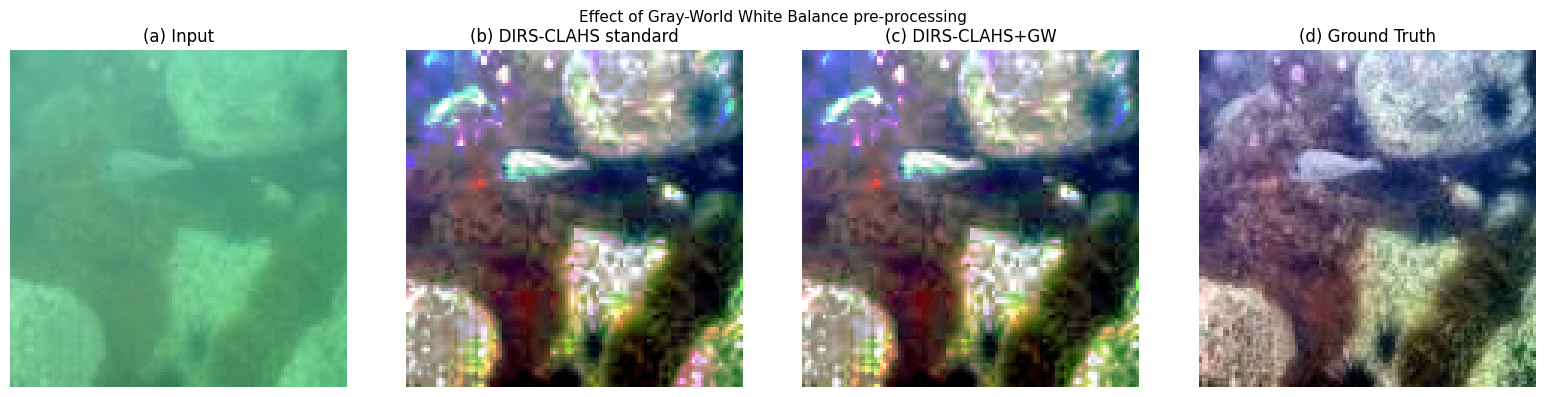

In [ ]:
best_img, best_name, best_score = None, None, 0

for fname in os.listdir(os.path.join(EXTRACT_DIR, 'input_test')):
    path = os.path.join(EXTRACT_DIR, 'input_test', fname)
    img  = cv2.imread(path).astype(np.float64)
    b_mean = img[:,:,0].mean()   # BGR: [0]=B
    r_mean = img[:,:,2].mean()   # BGR: [2]=R
    diff   = b_mean - r_mean
    # We want moderate cast: diff between 15 and 40, and r_mean not too low
    if 15 < diff < 40 and r_mean > 40:
        score = diff
        if score > best_score:
            best_score = score
            best_name  = fname

print(f"Best image: {best_name}  (B−R diff = {best_score:.1f})")

sample  = load_image(os.path.join(EXTRACT_DIR, 'input_test', best_name))
std_out = dirs_clahs(sample)
gw_out  = dirs_clahs_enhanced(sample)
gt_path = os.path.join(EXTRACT_DIR, 'gt_test', best_name)
gt      = load_image(gt_path) if os.path.exists(gt_path) else None

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(sample);  axes[0].set_title('(a) Input');               axes[0].axis('off')
axes[1].imshow(std_out); axes[1].set_title('(b) DIRS-CLAHS standard'); axes[1].axis('off')
axes[2].imshow(gw_out);  axes[2].set_title('(c) DIRS-CLAHS+GW');       axes[2].axis('off')
if gt is not None:
    axes[3].imshow(gt);  axes[3].set_title('(d) Ground Truth');         axes[3].axis('off')
else:
    axes[3].axis('off'); axes[3].set_title('(d) GT not available')

plt.suptitle('Effect of Gray-World White Balance pre-processing', fontsize=11)
plt.tight_layout()
plt.savefig('/content/fig3_gw_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Get std dev for enhanced pipeline metrics
full_ref = df.dropna(subset=['psnr_std'])
print(f"PSNR Enh: {full_ref['psnr_enh'].mean():.3f} ±{full_ref['psnr_enh'].std():.3f}")
print(f"SSIM Enh: {full_ref['ssim_enh'].mean():.4f} ±{full_ref['ssim_enh'].std():.4f}")
print(f"MSE  Enh: {full_ref['mse_enh'].mean():.2f}  ±{full_ref['mse_enh'].std():.2f}")

PSNR Enh: 15.607 ±3.075
SSIM Enh: 0.6149 ±0.1589
MSE  Enh: 2321.01  ±1896.04
